In [1]:
import torch
import torch.nn as nn
import importlib
import base_project as bp
import torchvision.models as models
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### Setup

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # normalization values for ImageNet (ResNet)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_data = datasets.OxfordIIITPet(root='./dataset', split='trainval',
                                     download=False, transform=transform)
test_data  = datasets.OxfordIIITPet(root='./dataset', split='test',
                                     download=False, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False, num_workers=2)

### Train

Train 100% data set with best strategy: Fine-tune l layers simultaneously (S1, l=4)

Epoch 1/20 | Train loss: 3.6003, acc: 0.0870 | Test loss: 2.8298, acc: 0.3606
Epoch 2/20 | Train loss: 2.6702, acc: 0.3299 | Test loss: 2.0377, acc: 0.7209
Epoch 3/20 | Train loss: 2.0215, acc: 0.5832 | Test loss: 1.5390, acc: 0.8389
Epoch 4/20 | Train loss: 1.5958, acc: 0.7215 | Test loss: 1.2318, acc: 0.8714
Epoch 5/20 | Train loss: 1.3159, acc: 0.8005 | Test loss: 1.0530, acc: 0.8774
Epoch 6/20 | Train loss: 1.1215, acc: 0.8514 | Test loss: 0.9393, acc: 0.8880
Epoch 7/20 | Train loss: 0.9931, acc: 0.8780 | Test loss: 0.8598, acc: 0.8972
Epoch 8/20 | Train loss: 0.8862, acc: 0.8984 | Test loss: 0.8085, acc: 0.9016
Epoch 9/20 | Train loss: 0.8144, acc: 0.9163 | Test loss: 0.7718, acc: 0.9030
Epoch 10/20 | Train loss: 0.7459, acc: 0.9266 | Test loss: 0.7469, acc: 0.9022
Epoch 11/20 | Train loss: 0.7033, acc: 0.9372 | Test loss: 0.7223, acc: 0.9081
Epoch 12/20 | Train loss: 0.6505, acc: 0.9524 | Test loss: 0.7133, acc: 0.9087
Epoch 13/20 | Train loss: 0.6236, acc: 0.9622 | Test loss: 0.

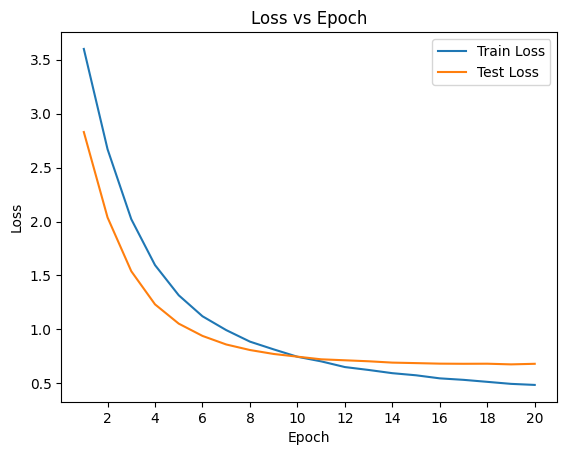

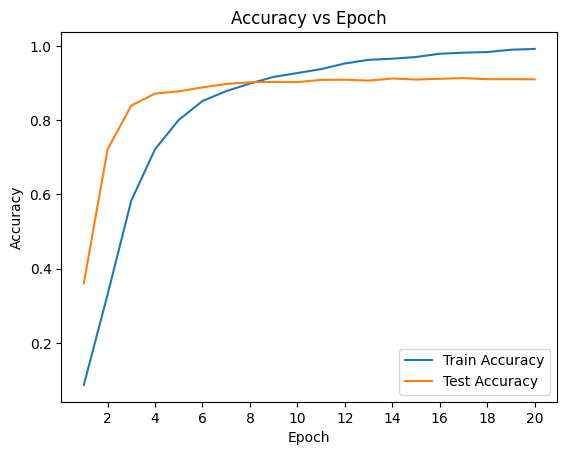

In [3]:
model     = bp.get_model_finetune_dropout(num_classes=37, dropout=0.5).to(device)
bp.unfreeze_layers(model, 4)
optimizer = bp.get_optimizer(model, 4, base_lr=1e-5)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

train_losses, test_losses, train_accs, test_accs, best_model, best_acc = bp.train_with_history(
    model, train_loader, test_loader, optimizer, criterion, device, num_epochs=20
)
model.load_state_dict(best_model)
torch.save(model.state_dict(), 'best_model.pth')
print(f"Best test acc: {best_acc:.4f}")
bp.plot_training_curves(train_losses, test_losses, train_accs, test_accs)